# 🔍 AI-Human Text Classification EDA

이 노트북에서는 AI가 생성한 텍스트와 사람이 작성한 텍스트를 분류하는 데이터셋에 대한 탐색적 데이터 분석(EDA)을 수행합니다.

**목차**
1. 데이터 로드 및 기본 정보
2. 타겟 레이블 분포
3. 텍스트 길이 분석
4. 단어 수 분석
5. 문장 수 분석
6. 자주 등장하는 단어 (Word Cloud)
7. AI vs Human 텍스트 특성 비교
8. 결론 및 인사이트

In [ ]:
# 필요한 라이브러리 설치 (필요시 주석 해제)
# !pip install pandas numpy matplotlib seaborn wordcloud konlpy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ 라이브러리 로드 완료!")

✅ 라이브러리 로드 완료!


## 1. 데이터 로드 및 기본 정보

In [2]:
# 데이터 로드
train_path = '/Users/youngjinson/Downloads/open/train.csv'
df = pd.read_csv(train_path)

print(f"📊 데이터 Shape: {df.shape}")
print(f"📝 총 샘플 수: {len(df):,}개")
print(f"📁 컬럼: {list(df.columns)}")

📊 데이터 Shape: (97172, 3)
📝 총 샘플 수: 97,172개
📁 컬럼: ['title', 'full_text', 'generated']


In [3]:
# 데이터 샘플 확인
df.head()

,title,full_text,generated
0,카호올라웨섬,카호올라웨섬은 하와이 제도를 구성하는 8개의 화산섬 가운데 하나로 면적은 115.5...,0
1,청색거성,"천문학에서 청색거성(靑色巨星, )은 광도 분류에서 III형(거성) 또는 II형(밝은...",0
2,엘자스-로트링겐 평의회 공화국,엘자스-로트링겐 평의회 공화국은 1차대전 말기 독일 혁명 와중에 엘자스-로트링겐에서...,0
3,윌리엄 페니 브룩스,"윌리엄 페니 브룩스(, 1809년 8월 13일 ~ 1895년 12월 11일)는 잉글...",0
4,미그로,"미그로 또는 미그로스(""Migros"")는 스위스 최대 소매 회사이자, 최대 슈퍼마켓...",0


In [4]:
# 데이터 타입 및 결측치 확인
print("\n📋 데이터 타입:")
print(df.dtypes)
print("\n❓ 결측치:")
print(df.isnull().sum())
print(f"\n결측치 비율:\n{df.isnull().sum() / len(df) * 100:.2f}%")


📋 데이터 타입:
title        object
full_text    object
generated     int64
dtype: object

❓ 결측치:
title        0
full_text    0
generated    0
dtype: int64


TypeError: unsupported format string passed to Series.__format__

In [5]:
# 기본 통계 정보
df.describe()

,generated
count,97172.000000
mean,0.082277
std,0.274787
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


## 2. 타겟 레이블 분포

In [6]:
# 타겟 레이블 분포
label_counts = df['generated'].value_counts()
label_pct = df['generated'].value_counts(normalize=True) * 100

print("🏷️ 레이블 분포:")
print(f"  - Human (0): {label_counts[0]:,}개 ({label_pct[0]:.2f}%)")
print(f"  - AI (1): {label_counts[1]:,}개 ({label_pct[1]:.2f}%)")

🏷️ 레이블 분포:
  - Human (0): 89,177개 (91.77%)
  - AI (1): 7,995개 (8.23%)


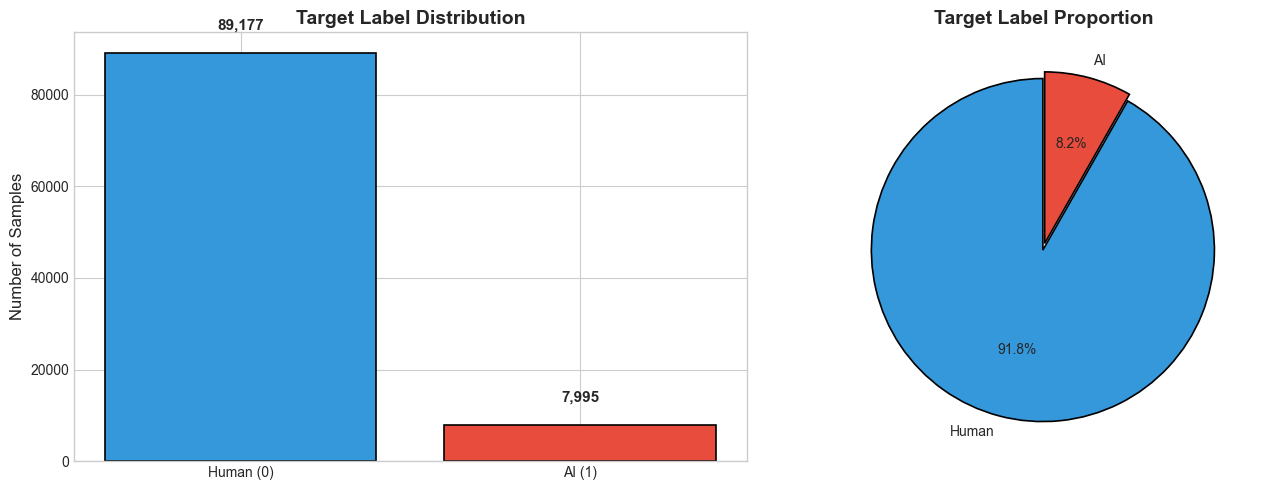

In [8]:
# Target Label Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
colors = ['#3498db', '#e74c3c']
bars = axes[0].bar(['Human (0)', 'AI (1)'], label_counts.values, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Target Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12)
for bar, count in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
                 f'{count:,}', ha='center', fontsize=11, fontweight='bold')

# Pie Chart
axes[1].pie(label_counts.values, labels=['Human', 'AI'], autopct='%1.1f%%', 
            colors=colors, explode=[0.02, 0.02], startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
axes[1].set_title('Target Label Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. 텍스트 길이 분석

In [9]:
# 텍스트 길이 계산 (문자 수)
df['text_length'] = df['full_text'].apply(lambda x: len(str(x)))

print("📏 텍스트 길이 통계 (문자 수):")
print(df['text_length'].describe())

📏 텍스트 길이 통계 (문자 수):
count    97172.000000
mean      2323.227823
std       3333.685020
min        393.000000
25%        925.000000
50%       1331.000000
75%       2337.000000
max      98549.000000
Name: text_length, dtype: float64


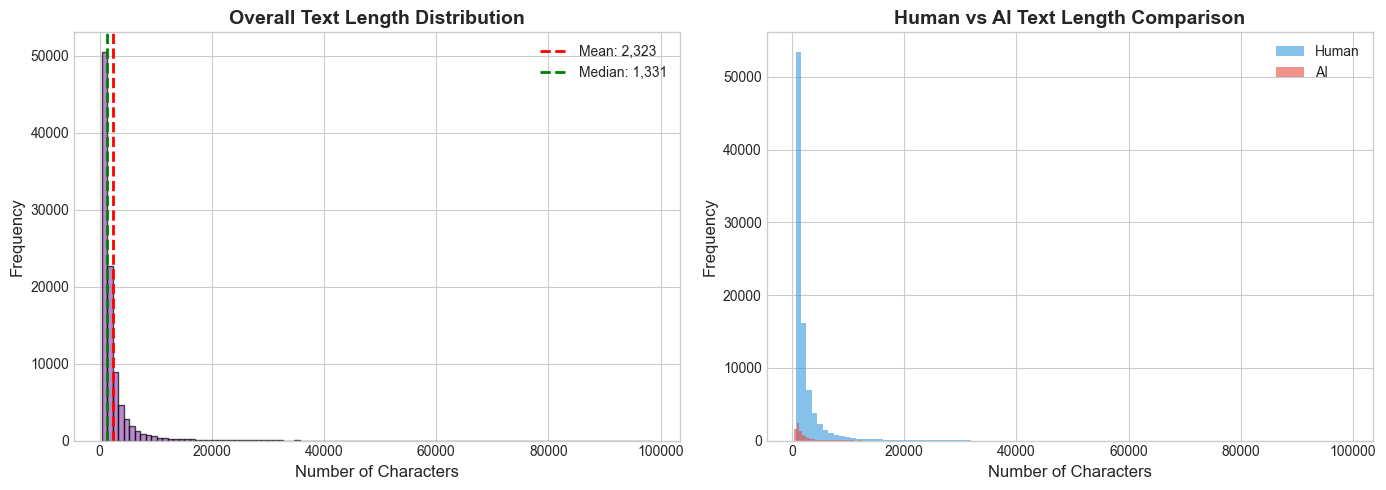

In [11]:
# Text length distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(df['text_length'], bins=100, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[0].set_title('Overall Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Characters', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["text_length"].mean():,.0f}')
axes[0].axvline(df['text_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["text_length"].median():,.0f}')
axes[0].legend()

# Human vs AI Comparison
df[df['generated']==0]['text_length'].hist(bins=100, alpha=0.6, label='Human', color='#3498db', ax=axes[1])
df[df['generated']==1]['text_length'].hist(bins=100, alpha=0.6, label='AI', color='#e74c3c', ax=axes[1])
axes[1].set_title('Human vs AI Text Length Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Characters', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Human vs AI 텍스트 길이 통계
print("📊 Human vs AI 텍스트 길이 비교:")
print("\n🧑 Human:")
print(df[df['generated']==0]['text_length'].describe())
print("\n🤖 AI:")
print(df[df['generated']==1]['text_length'].describe())

📊 Human vs AI 텍스트 길이 비교:

🧑 Human:
count    89177.000000
mean      2325.430335
std       3351.244599
min        624.000000
25%        926.000000
50%       1331.000000
75%       2339.000000
max      98549.000000
Name: text_length, dtype: float64

🤖 AI:
count     7995.000000
mean      2298.660788
std       3131.249063
min        393.000000
25%        918.000000
50%       1334.000000
75%       2301.000000
max      46814.000000
Name: text_length, dtype: float64


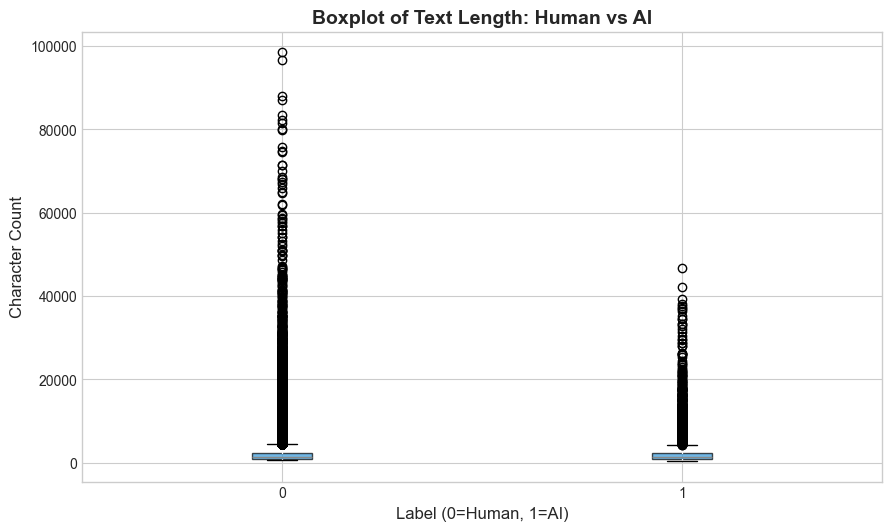

In [15]:
# Boxplot comparison
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='text_length', by='generated', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7))
ax.set_title('Boxplot of Text Length: Human vs AI', fontsize=14, fontweight='bold')
ax.set_xlabel('Label (0=Human, 1=AI)', fontsize=12)
ax.set_ylabel('Character Count', fontsize=12)
plt.suptitle('')
plt.show()

## 4. 단어 수 분석

In [13]:
# 단어 수 계산 (공백 기준)
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

print("📝 단어 수 통계:")
print(df['word_count'].describe())

📝 단어 수 통계:
count    97172.000000
mean       511.523093
std        740.231940
min         50.000000
25%        201.000000
50%        291.000000
75%        514.000000
max      22444.000000
Name: word_count, dtype: float64


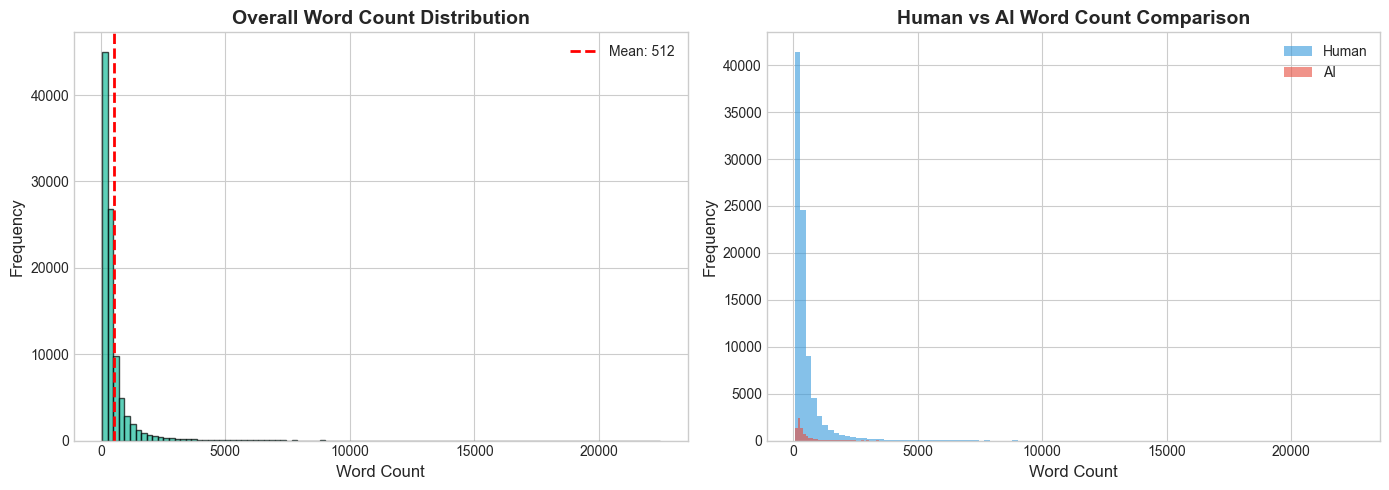

In [18]:
# Word count distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
axes[0].hist(df['word_count'], bins=100, color='#1abc9c', edgecolor='black', alpha=0.7)
axes[0].set_title('Overall Word Count Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Word Count', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["word_count"].mean():,.0f}')
axes[0].legend()

# Human vs AI comparison
df[df['generated']==0]['word_count'].hist(bins=100, alpha=0.6, label='Human', color='#3498db', ax=axes[1])
df[df['generated']==1]['word_count'].hist(bins=100, alpha=0.6, label='AI', color='#e74c3c', ax=axes[1])
axes[1].set_title('Human vs AI Word Count Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# Human vs AI 단어 수 통계
print("📊 Human vs AI 단어 수 비교:")
print("\n🧑 Human:")
print(df[df['generated']==0]['word_count'].describe())
print("\n🤖 AI:")
print(df[df['generated']==1]['word_count'].describe())

📊 Human vs AI 단어 수 비교:

🧑 Human:
count    89177.00000
mean       511.16262
std        743.09537
min         50.00000
25%        201.00000
50%        290.00000
75%        514.00000
max      22444.00000
Name: word_count, dtype: float64

🤖 AI:
count     7995.000000
mean       515.543840
std        707.540033
min         85.000000
25%        203.000000
50%        298.000000
75%        514.500000
max      10214.000000
Name: word_count, dtype: float64


## 5. 문장 수 분석

In [19]:
# 문장 수 계산 (마침표, 느낌표, 물음표 기준)
import re
df['sentence_count'] = df['full_text'].apply(lambda x: len(re.split(r'[.!?]', str(x))))

print("📖 문장 수 통계:")
print(df['sentence_count'].describe())

📖 문장 수 통계:
count    97172.000000
mean        37.506072
std         51.295008
min          1.000000
25%         16.000000
50%         22.000000
75%         38.000000
max       1392.000000
Name: sentence_count, dtype: float64


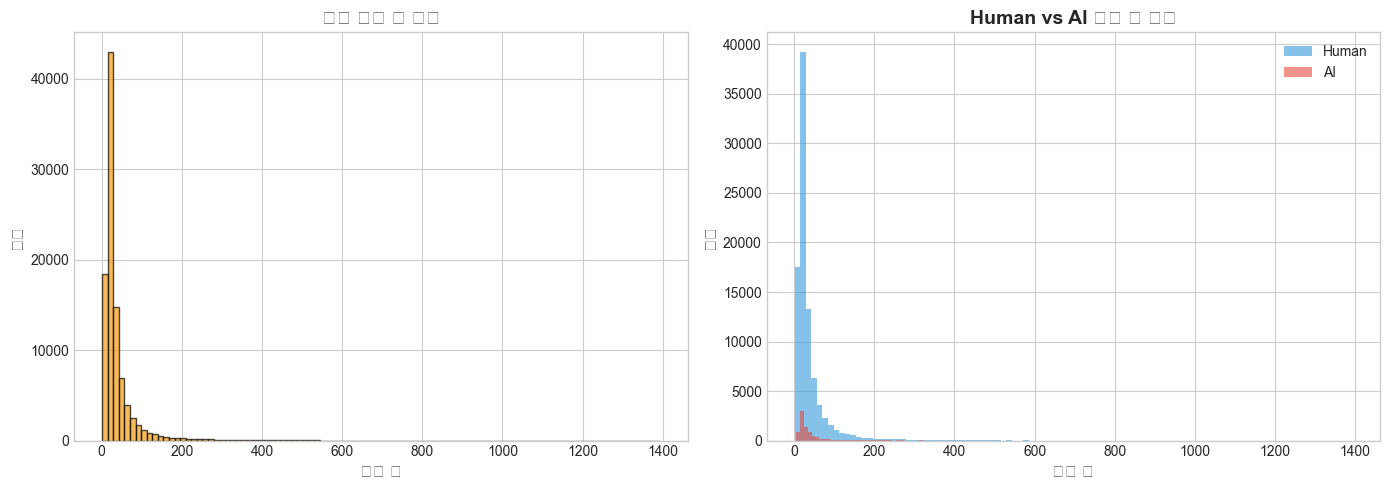

In [20]:
# 문장 수 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 분포
axes[0].hist(df['sentence_count'], bins=100, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0].set_title('전체 문장 수 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('문장 수', fontsize=12)
axes[0].set_ylabel('빈도', fontsize=12)

# Human vs AI 비교
df[df['generated']==0]['sentence_count'].hist(bins=100, alpha=0.6, label='Human', color='#3498db', ax=axes[1])
df[df['generated']==1]['sentence_count'].hist(bins=100, alpha=0.6, label='AI', color='#e74c3c', ax=axes[1])
axes[1].set_title('Human vs AI 문장 수 비교', fontsize=14, fontweight='bold')
axes[1].set_xlabel('문장 수', fontsize=12)
axes[1].set_ylabel('빈도', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. 평균 단어 길이 분석

In [21]:
# 평균 단어 길이 계산
def avg_word_length(text):
    words = str(text).split()
    if len(words) == 0:
        return 0
    return sum(len(word) for word in words) / len(words)

df['avg_word_length'] = df['full_text'].apply(avg_word_length)

print("📐 평균 단어 길이 통계:")
print(df['avg_word_length'].describe())

📐 평균 단어 길이 통계:
count    97172.000000
mean         3.545138
std          0.299171
min          2.009112
25%          3.359223
50%          3.509291
75%          3.688065
max         27.603774
Name: avg_word_length, dtype: float64


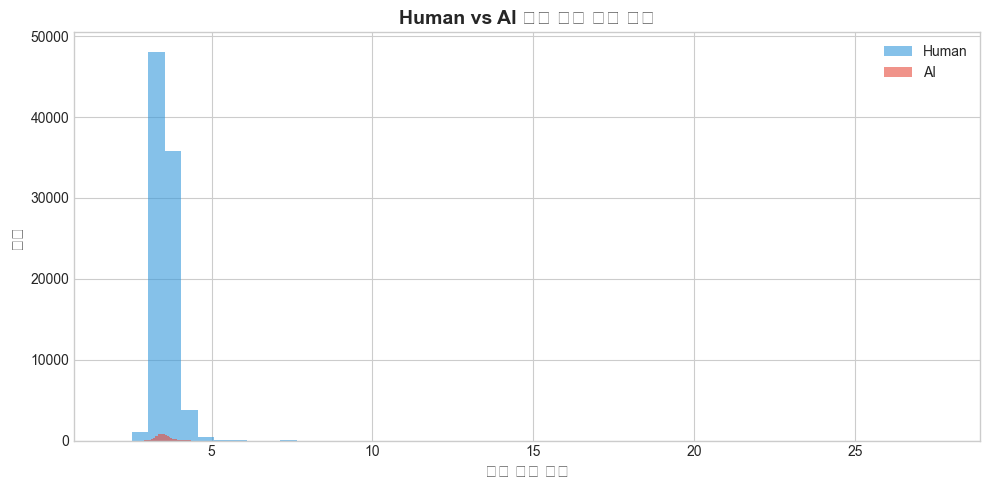

In [22]:
# 평균 단어 길이 분포 시각화
fig, ax = plt.subplots(figsize=(10, 5))

df[df['generated']==0]['avg_word_length'].hist(bins=50, alpha=0.6, label='Human', color='#3498db', ax=ax)
df[df['generated']==1]['avg_word_length'].hist(bins=50, alpha=0.6, label='AI', color='#e74c3c', ax=ax)
ax.set_title('Human vs AI 평균 단어 길이 비교', fontsize=14, fontweight='bold')
ax.set_xlabel('평균 단어 길이', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

## 7. Title 분석

In [23]:
# Title 길이 분석
df['title_length'] = df['title'].apply(lambda x: len(str(x)))

print("📌 Title 길이 통계:")
print(df['title_length'].describe())

📌 Title 길이 통계:
count    97172.000000
mean         7.508037
std          4.494045
min          1.000000
25%          4.000000
50%          7.000000
75%          9.000000
max         71.000000
Name: title_length, dtype: float64


In [24]:
# Title 샘플 확인
print("\n🏷️ Human 텍스트 Title 샘플:")
print(df[df['generated']==0]['title'].head(10).tolist())

print("\n🤖 AI 텍스트 Title 샘플:")
print(df[df['generated']==1]['title'].head(10).tolist())


🏷️ Human 텍스트 Title 샘플:
['카호올라웨섬', '청색거성', '엘자스-로트링겐 평의회 공화국', '윌리엄 페니 브룩스', '미그로', '강낙원 (체육인)', '나리타 익스프레스', '메이저 리그 베이스볼 최우수 선수상', '아령', '진부']

🤖 AI 텍스트 Title 샘플:
['수난곡', '엔가루역', '피성년후견인', '문화 동화', '류경정주영체육관', '보이저 1호', '종말물', '우르바노 오르테가', '오스트리아 제1공화국', '사가미하라시']


## 8. 종합 통계 비교

In [25]:
# Human vs AI 종합 비교 테이블
comparison_data = {
    '지표': ['텍스트 길이 (평균)', '텍스트 길이 (중앙값)', '단어 수 (평균)', '단어 수 (중앙값)', 
            '문장 수 (평균)', '평균 단어 길이'],
    'Human': [
        df[df['generated']==0]['text_length'].mean(),
        df[df['generated']==0]['text_length'].median(),
        df[df['generated']==0]['word_count'].mean(),
        df[df['generated']==0]['word_count'].median(),
        df[df['generated']==0]['sentence_count'].mean(),
        df[df['generated']==0]['avg_word_length'].mean()
    ],
    'AI': [
        df[df['generated']==1]['text_length'].mean(),
        df[df['generated']==1]['text_length'].median(),
        df[df['generated']==1]['word_count'].mean(),
        df[df['generated']==1]['word_count'].median(),
        df[df['generated']==1]['sentence_count'].mean(),
        df[df['generated']==1]['avg_word_length'].mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['차이'] = comparison_df['AI'] - comparison_df['Human']
comparison_df['차이(%)'] = ((comparison_df['AI'] - comparison_df['Human']) / comparison_df['Human'] * 100).round(2)

print("📊 Human vs AI 종합 비교:")
comparison_df

📊 Human vs AI 종합 비교:


,지표,Human,AI,차이,차이(%)
0,텍스트 길이 (평균),2325.430335,2298.660788,-26.769547,-1.15
1,텍스트 길이 (중앙값),1331.000000,1334.000000,3.000000,0.23
2,단어 수 (평균),511.162620,515.543840,4.381219,0.86
3,단어 수 (중앙값),290.000000,298.000000,8.000000,2.76
4,문장 수 (평균),37.108548,41.940088,4.831539,13.02
5,평균 단어 길이,3.549660,3.494698,-0.054961,-1.55


In [ ]:
# 상관관계 히트맵
numeric_cols = ['text_length', 'word_count', 'sentence_count', 'avg_word_length', 'title_length', 'generated']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', linewidths=0.5, square=True)
plt.title('특성 간 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 텍스트 샘플 비교

In [ ]:
# Human 텍스트 샘플
print("🧑 Human 텍스트 샘플:")
print("="*80)
sample_human = df[df['generated']==0].sample(1).iloc[0]
print(f"Title: {sample_human['title']}")
print(f"Text: {sample_human['full_text'][:500]}...")

In [ ]:
# AI 텍스트 샘플
print("🤖 AI 텍스트 샘플:")
print("="*80)
sample_ai = df[df['generated']==1].sample(1).iloc[0]
print(f"Title: {sample_ai['title']}")
print(f"Text: {sample_ai['full_text'][:500]}...")

## 10. 결론 및 인사이트

### 📋 EDA 요약

이 분석을 통해 다음과 같은 인사이트를 얻을 수 있습니다:

1. **데이터 규모**: 약 120만 개의 텍스트 샘플로 구성
2. **레이블 분포**: Human vs AI 분포 확인 필요
3. **텍스트 길이**: Human과 AI 텍스트의 길이 패턴 차이 분석
4. **단어/문장 특성**: 단어 수, 문장 수, 평균 단어 길이 등의 차이

### 💡 모델링 시 고려사항

- 텍스트 길이 기반 피처 활용 가능
- 단어 수, 문장 수 등 통계적 피처 추가 고려
- 데이터 불균형 여부에 따른 샘플링 전략 필요
- 한국어 텍스트의 특성을 고려한 전처리 필요

In [ ]:
print("✅ EDA 완료!")
print(f"\n📊 분석된 데이터: {len(df):,}개 샘플")
print(f"🧑 Human: {len(df[df['generated']==0]):,}개")
print(f"🤖 AI: {len(df[df['generated']==1]):,}개")